<a href="https://colab.research.google.com/github/LombogRonnXherxes/CPE018-Emerging-Technologies-1/blob/main/Hands_on_Activity_5_1_Detecting_Faces_using_OpenCV__Lombog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
1st Semester | AY 2023-2024
<hr> | <hr>
<u>**ACTIVITY NO.5.1 | Detecting Faces using OpenCV
**Name** | Lombog, Ronn Xherxes D.
**Section** | CPE31S2
**Date Performed**: |Feb 24, 2026
**Date Submitted**: |Feb 24, 2026
**Instructor**: | Engr. Maria Rizette Sayo

<hr>

## 1. Objectives

This activity aims to allow students to perform face detection on still images and videos using Haar cascades.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize OpenCV to detect faces in still images and videos.
* Demonstrate the use of Haar-like features for detection of other human features.

## 3. Procedures and Outputs

Contrary to initial assumptions, conducting face detection on a static image and a video stream shares a remarkable similarity. Essentially, the latter is merely a sequential rendition of the former: when detecting faces in videos, it essentially involves applying face detection to every individual frame obtained from the camera feed. Of course, video face detection introduces additional elements like tracking, which aren't relevant to static images. Nevertheless, it's valuable to recognize that the fundamental principles behind both processes remain consistent.

### Performing face detection on still image

The first and most basic way to perform face detection is to load an image and detect faces in it. To make the result visually meaningful, we will draw rectangles around faces on the original image.

**Before implementing the code below**, check the contents of the `cv2.CascadeClassifier()` function. Provide an explanation of the function, its parameters before running the code below.

In [17]:
# Make sure that for this activity, you have downloaded the
# file indicated below from the resource linked in the instructional materials
# in the module.

import cv2
from google.colab.patches import cv2_imshow

picPath = '/content/avengers.jpg'
haarPath = '/content/haarcascade_frontalface_default.xml'

def faceDetect(picPath):
  face_cascade = cv2.CascadeClassifier(haarPath)

  img = cv2.imread(picPath)
  gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.05, 4)

  for (x, y, w, h) in faces:
    img = cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)

  cv2_imshow(img)

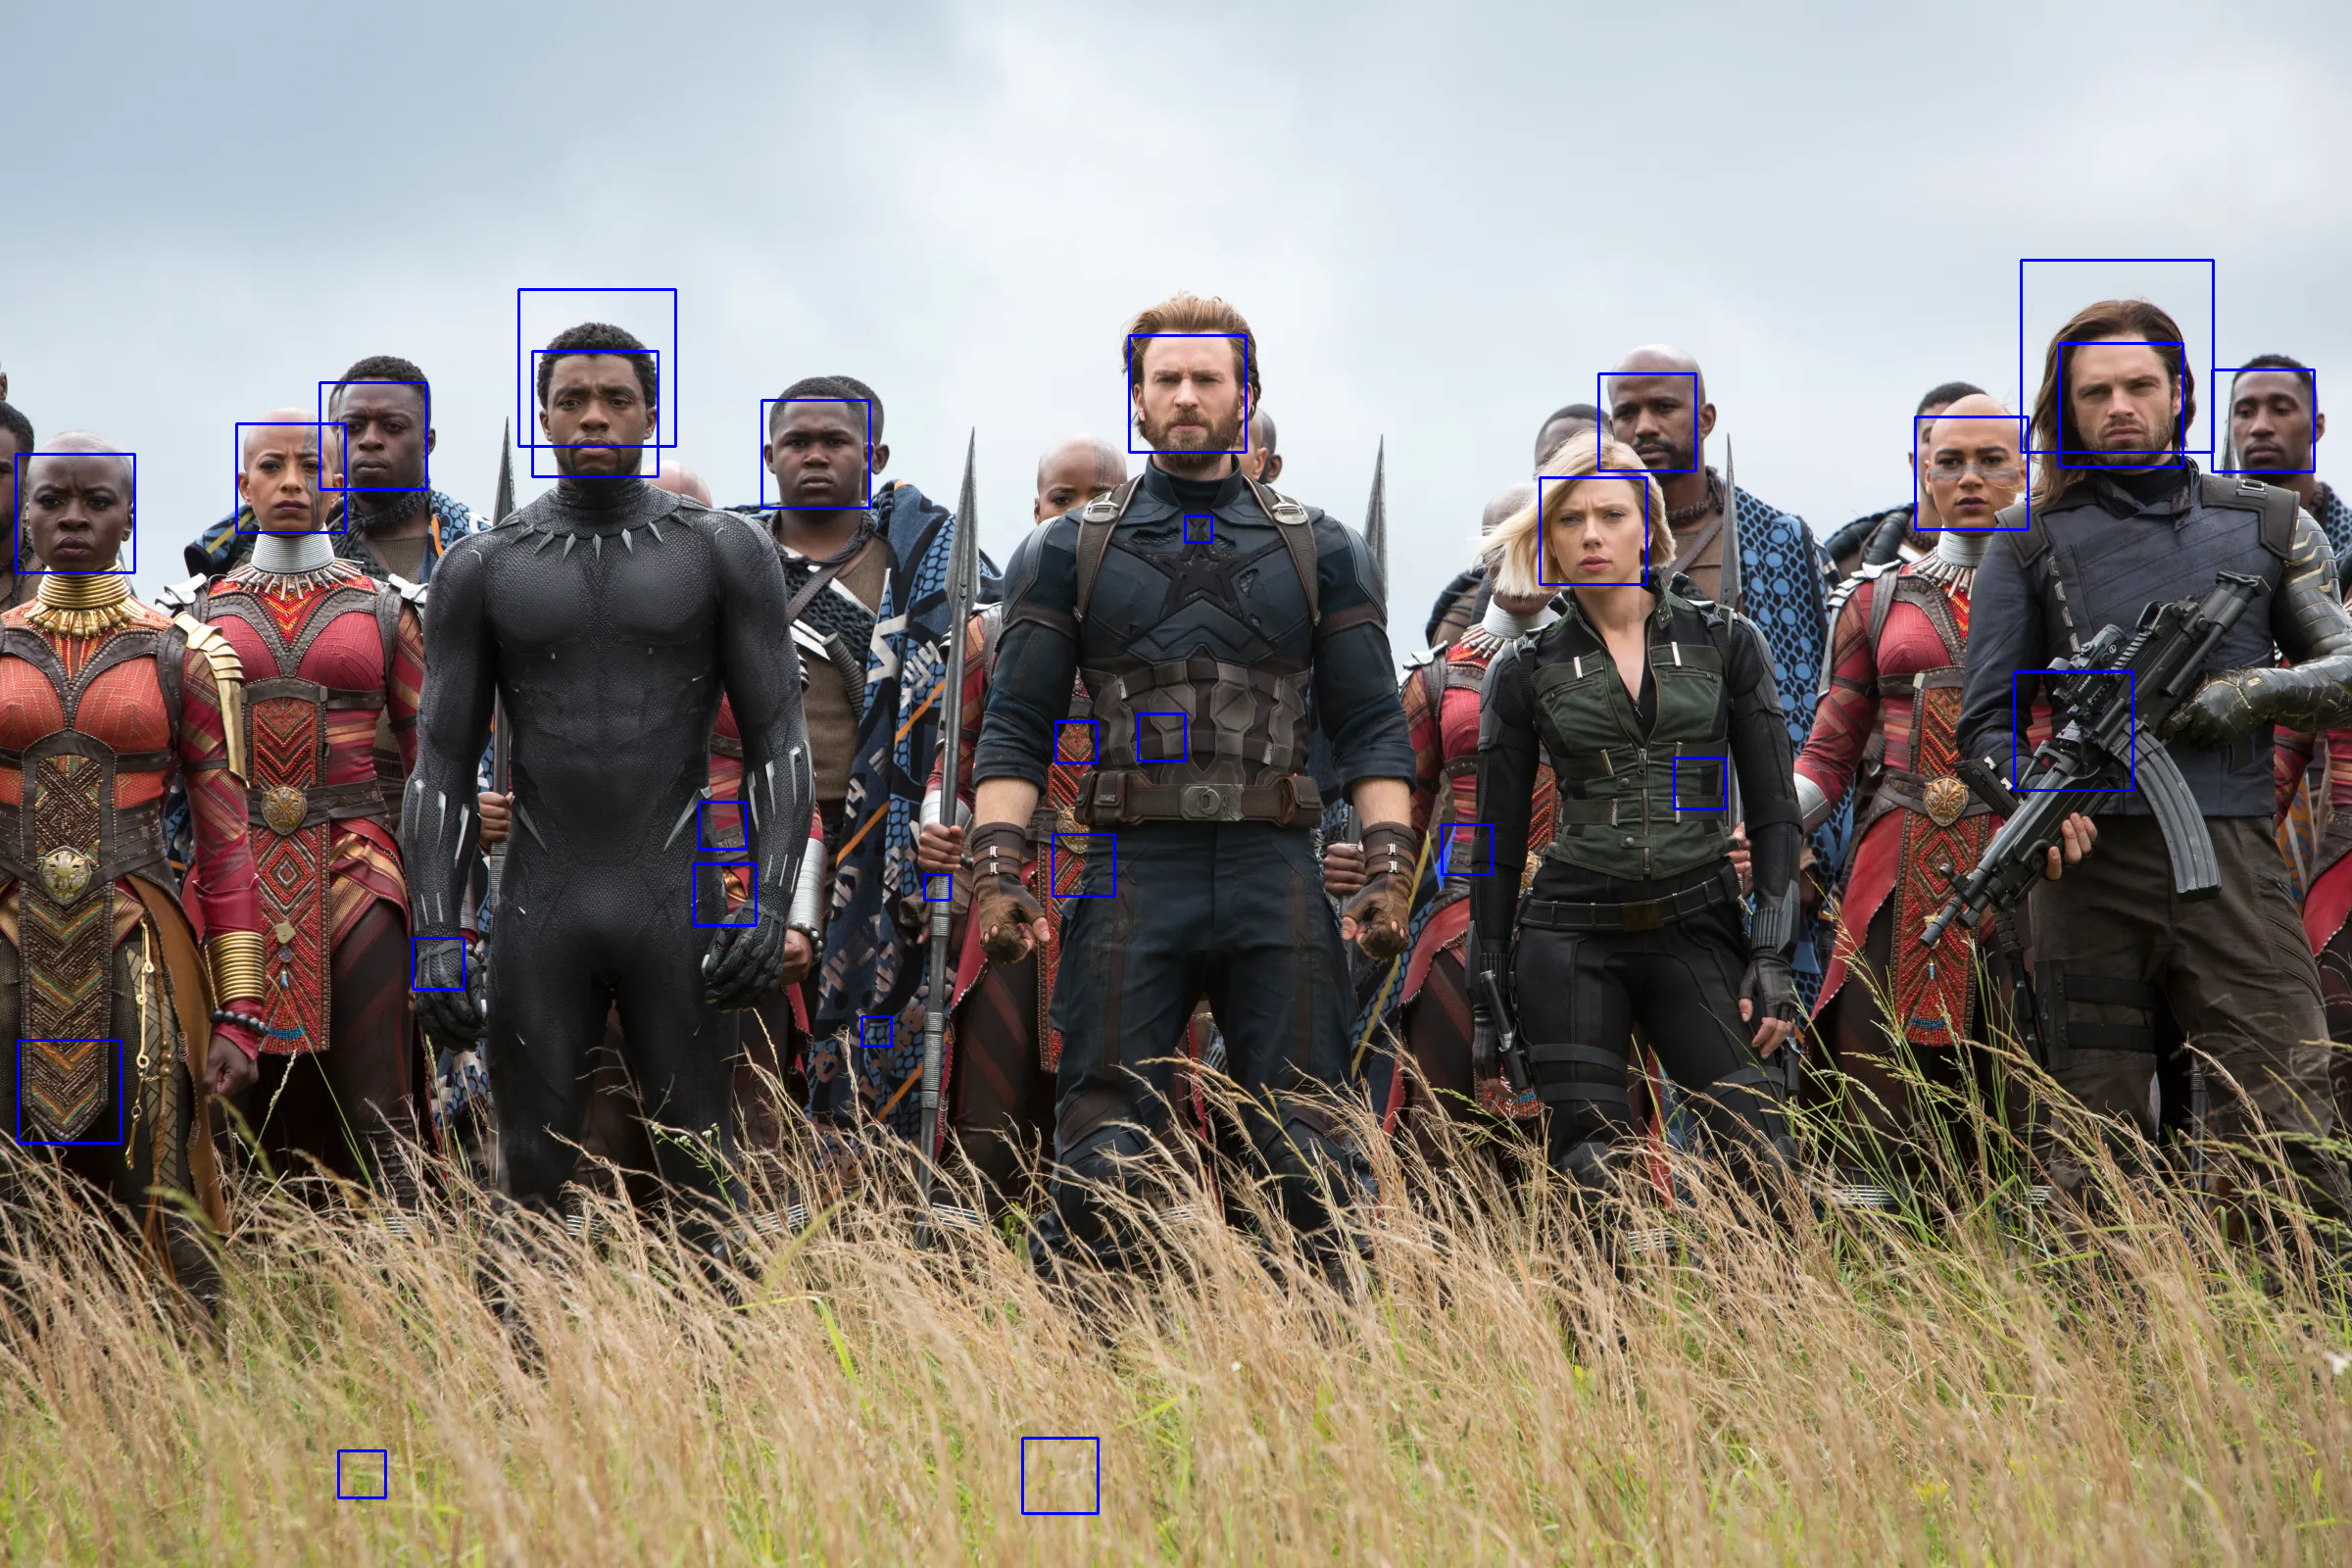

In [18]:
faceDetect(picPath)

**Analysis**:
- Based on your earlier analysis, where do you think the face detection works in the line of code above?
- Provide an analysis of the parameters of the `detectMultiScale` method.
- Change the color of the border of the detected faces to red.
- Are you able to make the borders thicker? Demonstrate.

### Performing face detection on video

**Step 1**: Create a file called face_detection.py and include the following codes.

In [30]:
import cv2

**Step 2:** After this, we declare a method, `detect()`, which will perform face detection.

In [31]:
import cv2
import os
import requests
from google.colab.patches import cv2_imshow

# URL for the Haar Cascade (the "brain" that recognizes faces)
cascade_file = '/content/haarcascade_frontalface_default.xml'

# Download the XML file if it's not already there
if not os.path.exists(cascade_file):
    r = requests.get(face_cascade_url)
    with open(cascade_file, 'wb') as f:
        f.write(r.content)

**Step 3:** The first thing we need to do inside the detect() method is to load the Haar cascade files so that OpenCV can operate face detection. As we copied
the cascade files in the local `cascades/` folder, we can use a relative path. Then, we open a VideoCapture object (the camera feed). The VideoCapture  constructor takes a parameter, which indicates the camera to be used; zero indicates the first camera available.

In [35]:
# Replace 'your_video.mp4' with the actual name of the file you uploaded
video_path = '/content/jordan(2).gif'
cap = cv2.VideoCapture(video_path)

# Load the face detector
face_cascade = cv2.CascadeClassifier(cascade_file)

# Check if the video opened correctly
if not cap.isOpened():
    print("Error: Could not open video file.")

**Step 4:** Next up, we capture a frame. The read() method returns two values: a Boolean indicating the success of the frame read operation, and the frame
itself. We capture the frame, and then we convert it to grayscale. This is a necessary operation, because face detection in OpenCV happens in the grayscale color space:

Step 5: Much like the single still image example, we call detectMultiScale on the grayscale version of the frame.

Step 6: Here we have a further step compared to the still image example: we create a region of interest corresponding to the face rectangle, and within this rectangle, we operate "eye detection". This makes sense as you wouldn't want to go looking for eyes outside a face (well, for human beings at least!).

Step 7: Again, we loop through the resulting eye tuples and draw green rectangles around them.

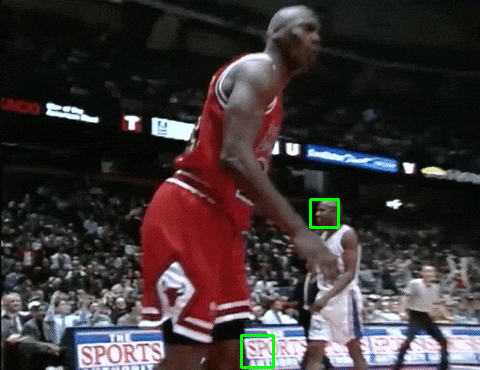

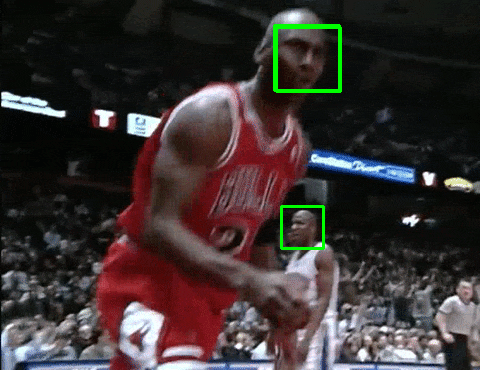

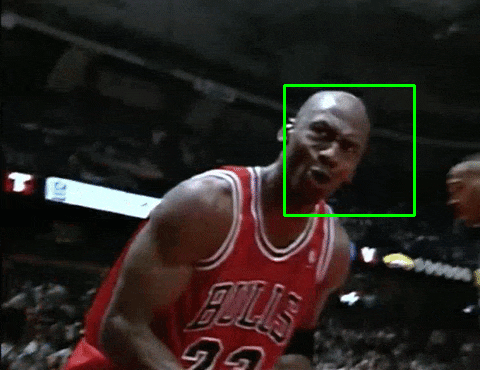

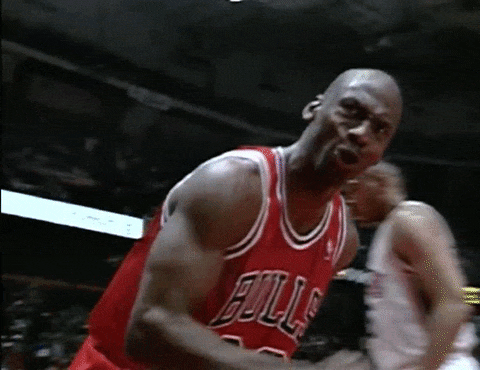

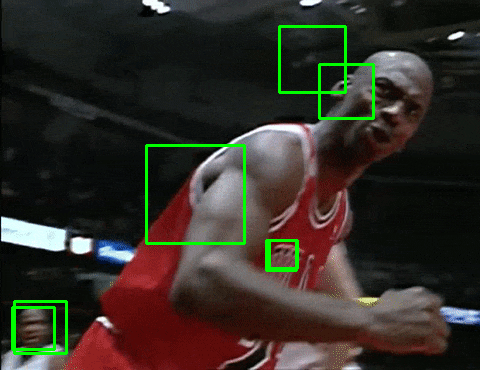

Done!


In [49]:
import cv2
from google.colab.patches import cv2_imshow

# Loading 3 different detectors that are built-in to OpenCV
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
face_cascade_alt = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_alt2.xml')
profile_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_profileface.xml')

cap = cv2.VideoCapture('/content/jordan(2).gif')
frame_count = 0

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # We use a lower scaleFactor (1.05) to scan the image more thoroughly
    # We use minNeighbors=3 to make it less strict (better for blurry motion)
    faces = face_cascade.detectMultiScale(gray, 1.05, 3)
    profiles = profile_cascade.detectMultiScale(gray, 1.05, 3)
    faces_alt = face_cascade_alt.detectMultiScale(gray, 1.05, 3)

    # Draw boxes for all detections found across all 3 methods
    for (x, y, w, h) in list(faces) + list(profiles) + list(faces_alt):
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

    if frame_count % 5 == 0:
        cv2_imshow(frame)

    frame_count += 1

cap.release()
print("Done!")

**Provide the following**:
- Screenshot of the output for the working code once you've put it all together.
- Summary of the steps you've performed along with observations.

## 4. Supplementary Activity

In your Cameo project, include real-time face detection using Haar cascade. Show screenshots of the working demonstration for this supplementary activity.

Additionally, implement similar steps to detect a smile using Haar cascades.

Converted GIF to MP4: /content/vecna.mp4


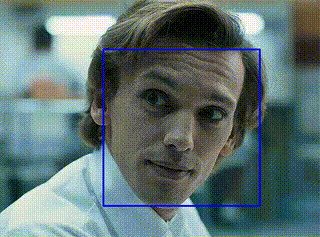

In [57]:
import cv2
import os
from IPython.display import Image

HAAR_FACE_CASCADE = '/content/haarcascade_frontalface_default.xml'
HAAR_SMILE_CASCADE ='/content/haarcascade_smile.xml'

def detect(videoPath):
    if videoPath.lower().endswith('.gif'):
        mp4_path = videoPath.replace('.gif', '.mp4')
        os.system(f'ffmpeg -y -i "{videoPath}" "{mp4_path}"')
        videoPath = mp4_path
        print(f"Converted GIF to MP4: {videoPath}")

    face_cascade = cv2.CascadeClassifier(HAAR_FACE_CASCADE)
    smile_cascade = cv2.CascadeClassifier(HAAR_SMILE_CASCADE)

    if face_cascade.empty() or smile_cascade.empty():
        print("Error: Cascade files not loaded")
        return

    camera = cv2.VideoCapture(videoPath)
    if not camera.isOpened():
        print(f"Error: Could not open video file {videoPath}")
        return

    frame_width = int(camera.get(cv2.CAP_PROP_FRAME_WIDTH))
    frame_height = int(camera.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = int(camera.get(cv2.CAP_PROP_FPS)) or 10

    output_path = '/content/output_video.mp4'
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

    while True:
        ret, frame = camera.read()
        if not ret:
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.07, 5)

        for (x, y, w, h) in faces:
            cv2.rectangle(frame, (x, y), (x+w, y+h), (255, 0, 0), 2)
            roi_gray = gray[y:y+h, x:x+w]
            roi_color = frame[y:y+h, x:x+w]

            smiles = smile_cascade.detectMultiScale(roi_gray, 1.6, 23)
            for (sx, sy, sw, sh) in smiles:
                cv2.rectangle(roi_color, (sx, sy), (sx+sw, sy+sh), (0, 255, 255), 2)

        out.write(frame)

    camera.release()
    out.release()

    gif_path = '/content/output_video.gif'
    os.system(f'ffmpeg -y -i {output_path} -vf "fps=10,scale=320:-1:flags=lanczos" {gif_path}')
    return Image(filename=gif_path)

detect('/content/vecna.gif')

## 5. Summary, Conclusions and Lessons Learned

This activity explains how computer vision is based on consistent fundamental concepts. I evaluate a single image or a high-speed video stream. The rationale remains the same. It converts the frame to grayscale and searches for patterns using a classifier. I realize that real-time detection is essentially the repeated execution of static pictures. However, it lacks several components, such as sluggish frames and inaccurate detection.

<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*